In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

In [5]:
data = pd.read_csv(r"/Users/pranayrastogi/PycharmProjects/ML_Zoomcamp/data/WA_Fn-UseC_-Telco-Customer-Churn.csv")
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
print(data.shape)
print(data.info())

(7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null

In [7]:
del data["customerID"]

In [8]:
data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [11]:
col_list = list()
for col in data.columns:
    col_list.append(col.lower().replace(" ", ""))

data.columns = col_list
data.head()

,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [12]:
categorical_cols = data.select_dtypes(include="object").columns
for col in categorical_cols:
    data[col] = data[col].str.lower().str.replace(" ","_")

data.head()

,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,female,0,yes,no,1,no,no_phone_service,dsl,no,yes,no,no,no,no,month-to-month,yes,electronic_check,29.85,29.85,no
1,male,0,no,no,34,yes,no,dsl,yes,no,yes,no,no,no,one_year,no,mailed_check,56.95,1889.5,no
2,male,0,no,no,2,yes,no,dsl,yes,yes,no,no,no,no,month-to-month,yes,mailed_check,53.85,108.15,yes
3,male,0,no,no,45,no,no_phone_service,dsl,yes,no,yes,yes,no,no,one_year,no,bank_transfer_(automatic),42.30,1840.75,no
4,female,0,no,no,2,yes,no,fiber_optic,no,no,no,no,no,no,month-to-month,yes,electronic_check,70.70,151.65,yes


In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   seniorcitizen     7043 non-null   int64  
 2   partner           7043 non-null   object 
 3   dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   phoneservice      7043 non-null   object 
 6   multiplelines     7043 non-null   object 
 7   internetservice   7043 non-null   object 
 8   onlinesecurity    7043 non-null   object 
 9   onlinebackup      7043 non-null   object 
 10  deviceprotection  7043 non-null   object 
 11  techsupport       7043 non-null   object 
 12  streamingtv       7043 non-null   object 
 13  streamingmovies   7043 non-null   object 
 14  contract          7043 non-null   object 
 15  paperlessbilling  7043 non-null   object 
 16  paymentmethod     7043 non-null   object 


In [17]:
temp = pd.to_numeric(data["totalcharges"], errors="coerce")

In [20]:
temp[temp.isnull()]

488    NaN
753    NaN
936    NaN
1082   NaN
1340   NaN
3331   NaN
3826   NaN
4380   NaN
5218   NaN
6670   NaN
6754   NaN
Name: totalcharges, dtype: float64

In [22]:
data.loc[488,"totalcharges"]

'_'

In [23]:
data["totalcharges"] = pd.to_numeric(data["totalcharges"], errors="coerce")
data["totalcharges"] = data["totalcharges"].fillna(data["monthlycharges"])

In [25]:
data.iloc[751:755,:]

,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
751,male,0,yes,yes,70,yes,no,dsl,yes,yes,yes,no,yes,yes,two_year,yes,credit_card_(automatic),80.15,5600.15,no
752,male,0,yes,yes,7,yes,no,dsl,yes,no,yes,yes,no,yes,month-to-month,yes,credit_card_(automatic),71.35,515.75,no
753,male,0,no,yes,0,yes,no,no,no_internet_service,no_internet_service,no_internet_service,no_internet_service,no_internet_service,no_internet_service,two_year,no,mailed_check,20.25,20.25,no
754,female,0,yes,no,2,yes,no,fiber_optic,yes,yes,no,no,yes,no,month-to-month,no,electronic_check,90.35,190.50,no


In [26]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   seniorcitizen     7043 non-null   int64  
 2   partner           7043 non-null   object 
 3   dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   phoneservice      7043 non-null   object 
 6   multiplelines     7043 non-null   object 
 7   internetservice   7043 non-null   object 
 8   onlinesecurity    7043 non-null   object 
 9   onlinebackup      7043 non-null   object 
 10  deviceprotection  7043 non-null   object 
 11  techsupport       7043 non-null   object 
 12  streamingtv       7043 non-null   object 
 13  streamingmovies   7043 non-null   object 
 14  contract          7043 non-null   object 
 15  paperlessbilling  7043 non-null   object 
 16  paymentmethod     7043 non-null   object 


In [27]:
categorical_cols = data.select_dtypes(include="object").columns

In [28]:
for col in categorical_cols:
    print(col)
    print(data[col].nunique())
    print(data[col].unique())
    print("-------------")

gender
2
['female' 'male']
-------------
partner
2
['yes' 'no']
-------------
dependents
2
['no' 'yes']
-------------
phoneservice
2
['no' 'yes']
-------------
multiplelines
3
['no_phone_service' 'no' 'yes']
-------------
internetservice
3
['dsl' 'fiber_optic' 'no']
-------------
onlinesecurity
3
['no' 'yes' 'no_internet_service']
-------------
onlinebackup
3
['yes' 'no' 'no_internet_service']
-------------
deviceprotection
3
['no' 'yes' 'no_internet_service']
-------------
techsupport
3
['no' 'yes' 'no_internet_service']
-------------
streamingtv
3
['no' 'yes' 'no_internet_service']
-------------
streamingmovies
3
['no' 'yes' 'no_internet_service']
-------------
contract
3
['month-to-month' 'one_year' 'two_year']
-------------
paperlessbilling
2
['yes' 'no']
-------------
paymentmethod
4
['electronic_check' 'mailed_check' 'bank_transfer_(automatic)'
 'credit_card_(automatic)']
-------------
churn
2
['no' 'yes']
-------------


In [30]:
data["churn"].value_counts(normalize=True)

churn
no     0.73463
yes    0.26537
Name: proportion, dtype: float64

In [31]:
data.isnull().sum()

gender              0
seniorcitizen       0
partner             0
dependents          0
tenure              0
phoneservice        0
multiplelines       0
internetservice     0
onlinesecurity      0
onlinebackup        0
deviceprotection    0
techsupport         0
streamingtv         0
streamingmovies     0
contract            0
paperlessbilling    0
paymentmethod       0
monthlycharges      0
totalcharges        0
churn               0
dtype: int64

In [37]:
data["churn"] = data["churn"].map({"no":0, "yes":1})

In [40]:
global_churn_rate = data.churn.mean()
global_churn_rate

np.float64(0.2653698707936959)

In [42]:
df_group = data.groupby("gender").churn.agg({"mean","count"})
df_group

,mean,count
gender,,
female,0.269209,3488
male,0.261603,3555


In [43]:
df_group = data.groupby("partner").churn.agg({"mean","count"})
df_group

,mean,count
partner,,
no,0.329580,3641
yes,0.196649,3402


In [45]:
df_group["diff"] = df_group["mean"] - global_churn_rate
df_group["risk"] = df_group["mean"] / global_churn_rate
df_group

,mean,count,diff,risk
partner,,,,
no,0.329580,3641,0.064210,1.241964
yes,0.196649,3402,-0.068721,0.741038


In [47]:
for col in categorical_cols:
    print(col)
    df_group = data.groupby(col).churn.agg({"mean","count"})
    df_group["diff"] = df_group["mean"] - global_churn_rate
    df_group["risk"] = df_group["mean"] / global_churn_rate
    print(df_group)
    print("====")

gender
            mean  count      diff      risk
gender                                     
female  0.269209   3488  0.003839  1.014466
male    0.261603   3555 -0.003766  0.985807
====
partner
             mean  count      diff      risk
partner                                     
no       0.329580   3641  0.064210  1.241964
yes      0.196649   3402 -0.068721  0.741038
====
dependents
                mean  count      diff      risk
dependents                                     
no          0.312791   4933  0.047422  1.178700
yes         0.154502   2110 -0.110868  0.582215
====
phoneservice
                  mean  count      diff      risk
phoneservice                                     
no            0.249267    682 -0.016103  0.939319
yes           0.267096   6361  0.001726  1.006506
====
multiplelines
                      mean  count      diff      risk
multiplelines                                        
no                0.250442   3390 -0.014927  0.943749
no_phone_service 

## Mutual Information

In [48]:
from sklearn.metrics import mutual_info_score

In [52]:
categorical_cols = list(categorical_cols)
categorical_cols.remove("churn")

In [53]:
categorical_cols


['gender',
 'partner',
 'dependents',
 'phoneservice',
 'multiplelines',
 'internetservice',
 'onlinesecurity',
 'onlinebackup',
 'deviceprotection',
 'techsupport',
 'streamingtv',
 'streamingmovies',
 'contract',
 'paperlessbilling',
 'paymentmethod']

In [58]:
def calculate_mutual_info_score(col1):
    return mutual_info_score(col1, data.churn)

In [63]:
mi = data[categorical_cols].apply(calculate_mutual_info_score)
mi.sort_values(ascending=False)

contract            0.098453
onlinesecurity      0.064677
techsupport         0.063021
internetservice     0.055574
onlinebackup        0.046792
paymentmethod       0.044519
deviceprotection    0.043917
streamingmovies     0.032001
streamingtv         0.031908
paperlessbilling    0.019194
dependents          0.014467
partner             0.011454
multiplelines       0.000801
phoneservice        0.000072
gender              0.000037
dtype: float64

## Correlation

In [69]:
numeric_cols = data.select_dtypes(include=[np.number]).columns
numeric_cols = list(numeric_cols)
numeric_cols.remove("seniorcitizen")
numeric_cols.remove("churn")
numeric_cols

['tenure', 'monthlycharges', 'totalcharges']

In [70]:
data[numeric_cols].corrwith(data.churn)

tenure           -0.352229
monthlycharges    0.193356
totalcharges     -0.198347
dtype: float64

(array([1612.,  759.,  570.,  556.,  495.,  494.,  452.,  495.,  501.,
        1109.]),
 array([ 0. ,  7.2, 14.4, 21.6, 28.8, 36. , 43.2, 50.4, 57.6, 64.8, 72. ]),
 <BarContainer object of 10 artists>)

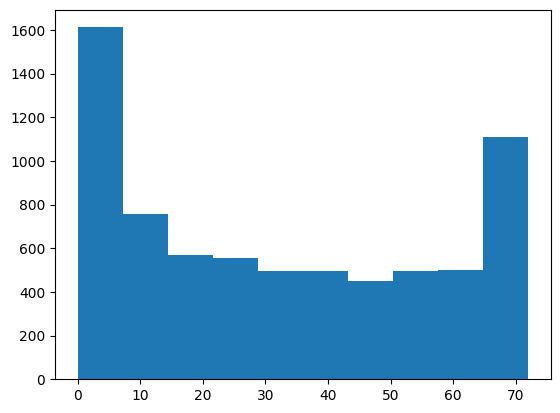

In [72]:
plt.hist(data.tenure)

In [73]:
data[data.tenure<15].churn.mean()

np.float64(0.5179900744416873)

In [74]:
data[(data.tenure>15) & (data.tenure<50)].churn.mean()

np.float64(0.22291666666666668)

In [75]:
data[(data.tenure>50)].churn.mean()

np.float64(0.08931116389548693)

In [93]:
df_full_train, df_test = train_test_split(data, test_size=0.2, random_state=1)
df_test.head()

,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
3381,female,0,no,no,41,yes,no,dsl,yes,no,yes,yes,yes,yes,one_year,yes,bank_transfer_(automatic),79.85,3320.75,0
6180,female,1,no,no,66,yes,yes,fiber_optic,yes,no,no,no,yes,yes,two_year,yes,bank_transfer_(automatic),102.40,6471.85,0
4829,female,0,no,no,12,yes,no,dsl,no,no,no,no,no,no,month-to-month,yes,bank_transfer_(automatic),45.00,524.35,0
3737,female,0,no,no,5,yes,yes,dsl,no,no,no,no,no,no,month-to-month,yes,mailed_check,50.60,249.95,1
4249,female,0,yes,yes,10,yes,no,dsl,no,yes,yes,no,no,yes,one_year,yes,mailed_check,65.90,660.05,0


In [94]:
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)
df_val.head()

,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
565,male,0,yes,yes,71,yes,no,dsl,yes,no,yes,yes,no,yes,two_year,yes,credit_card_(automatic),70.85,4973.40,0
199,male,0,no,yes,1,yes,no,no,no_internet_service,no_internet_service,no_internet_service,no_internet_service,no_internet_service,no_internet_service,month-to-month,no,mailed_check,20.75,20.75,0
6738,male,0,no,no,1,yes,no,no,no_internet_service,no_internet_service,no_internet_service,no_internet_service,no_internet_service,no_internet_service,month-to-month,no,mailed_check,20.35,20.35,0
2504,male,0,no,no,2,yes,no,fiber_optic,yes,no,no,no,no,no,month-to-month,yes,electronic_check,75.70,189.20,1
556,female,0,no,no,1,yes,no,no,no_internet_service,no_internet_service,no_internet_service,no_internet_service,no_internet_service,no_internet_service,month-to-month,no,bank_transfer_(automatic),19.90,19.90,0


In [95]:
len(df_train), len(df_val), len(df_test), len(data)

(4225, 1409, 1409, 7043)

In [96]:
y_train = df_train.churn.values
y_test = df_test.churn.values
y_val = df_val.churn.values

In [97]:
del df_train["churn"]
del df_test["churn"]
del df_val["churn"]

In [98]:
df_train = df_train.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)

In [99]:
from sklearn.preprocessing import OneHotEncoder

def prepare_features(df, categorical_cols, numerical_cols, encoder=None):
    """
    Performs one-hot encoding on categorical columns and
    returns a dataframe containing numerical columns +
    encoded categorical columns.

    Parameters:
    - df: pandas DataFrame
    - categorical_cols: list of categorical column names
    - numerical_cols: list of numerical column names
    - encoder: Optional pre-fitted OneHotEncoder (for test data)

    Returns:
    - X: processed feature DataFrame
    - encoder: fitted OneHotEncoder (for reuse on test data)
    """

    # Copy to avoid modifying original dataframe
    df = df.copy()

    # Initialize encoder if not provided
    if encoder is None:
        encoder = OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        )
        cat_encoded = encoder.fit_transform(df[categorical_cols])
    else:
        cat_encoded = encoder.transform(df[categorical_cols])

    # Get encoded column names
    cat_feature_names = encoder.get_feature_names_out(categorical_cols)

    # Create DataFrame for encoded features
    cat_df = pd.DataFrame(cat_encoded, columns=cat_feature_names, index=df.index)

    # Select numerical features
    num_df = df[numerical_cols]

    # Concatenate numerical + encoded categorical
    X = pd.concat([num_df, cat_df], axis=1)

    return X, encoder

In [100]:
df_train_ohe, encoder = prepare_features(df_train, categorical_cols, numeric_cols) 

In [ ]:
df_val_ohe, encoder = prepare_features(df_val, categorical_cols, numeric_cols)
df_test_ohe, encoder = prepare_features(df_test, categorical_cols, numeric_cols) 

In [84]:
print(categorical_cols)
print("---")
print(data.select_dtypes("object").columns)

['gender', 'partner', 'dependents', 'phoneservice', 'multiplelines', 'internetservice', 'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport', 'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling', 'paymentmethod']
---
Index(['gender', 'partner', 'dependents', 'phoneservice', 'multiplelines',
       'internetservice', 'onlinesecurity', 'onlinebackup', 'deviceprotection',
       'techsupport', 'streamingtv', 'streamingmovies', 'contract',
       'paperlessbilling', 'paymentmethod'],
      dtype='object')


In [85]:
print(numeric_cols)

['tenure', 'monthlycharges', 'totalcharges']
